In [ ]:
import biom

biom_file = "/workspaces/qiime2_blog/support_data/feature-table.biom"
table = biom.load_table(biom_file)

In [35]:
sequence_num_list = []
sample_num_list = []
sum_asv_list = []


for sequence_num in range(100,4000,100):
    sub_table = table.subsample(sequence_num, axis='sample', by_id=False, seed=0)
    sample_num_list.append(len(sub_table._sample_ids))
    sequence_num_list.append(sequence_num)
    sum_asv_list.append(sub_table.sum(axis='sample').sum())

/tmp/ipykernel_58142/2121510468.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels([f'{int(t/1000)}k' for t in ticks])


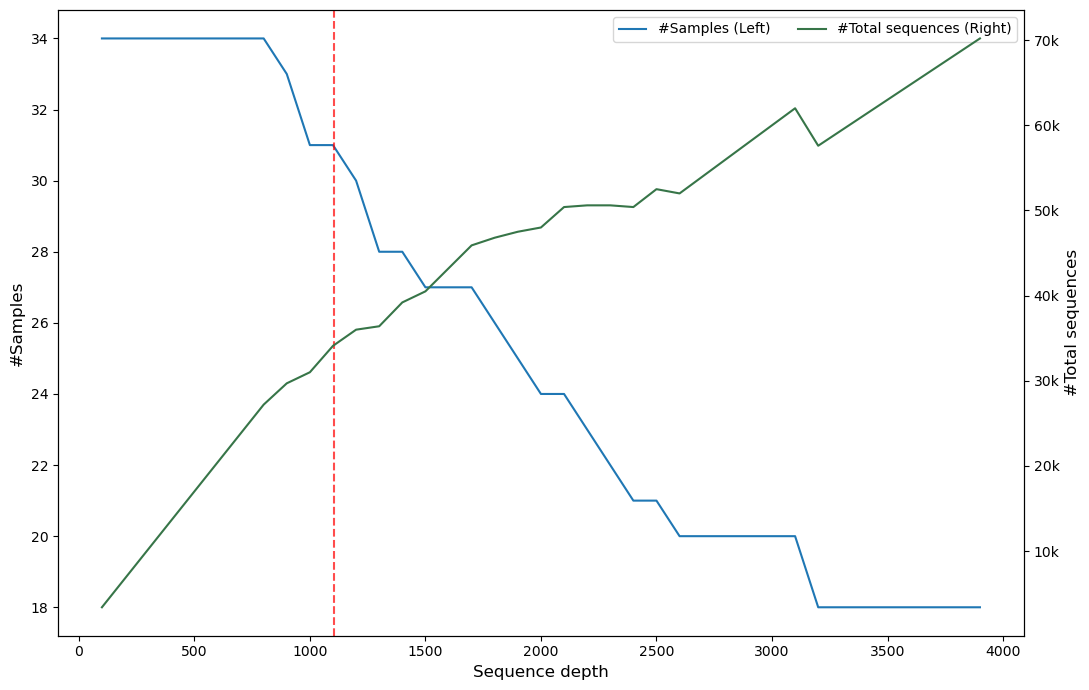

In [70]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (11, 7) 

fig, ax1 = plt.subplots()

ax1.set_xlabel('Sequence depth', fontsize=12)
ax1.set_ylabel('#Samples', fontsize=12)
line1 = ax1.plot(sequence_num_list, sample_num_list, label="#Samples (Left)")
ax1.tick_params(axis='y', labelsize=10)

ax2 = ax1.twinx()  
ax2.set_ylabel('#Total sequences', fontsize=12)
line2 = ax2.plot(sequence_num_list, sum_asv_list, label="#Total sequences (Right)", color="#377548")
ax2.tick_params(axis='y', labelsize=10)

ticks = ax2.get_yticks()
ax2.set_yticklabels([f'{int(t/1000)}k' for t in ticks])

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', ncol=3, frameon=True)

ax1.axvline(x=1103, color='red', linestyle='--', linewidth=1.5, label='Threshold (1103)', alpha=0.7)

plt.tight_layout()
plt.savefig('/workspaces/qiime2_blog/docs/static/rarefraction_view.png', dpi=300, bbox_inches='tight') 